In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/Loan_default.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## Understanding the data

In [3]:
print(f'Data has {df.shape[0]} rows and {df.shape[1]} columns')

Data has 255347 rows and 18 columns


In [4]:
print("Columns:", df.columns)

Columns: Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='str')


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [6]:
# Checking null values
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [7]:
df.duplicated().sum()   

np.int64(0)

In [8]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [9]:
df.dtypes

LoanID                str
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education             str
EmploymentType        str
MaritalStatus         str
HasMortgage           str
HasDependents         str
LoanPurpose           str
HasCoSigner           str
Default             int64
dtype: object

In [10]:
# Dropped redundant columns
df.drop(columns=['LoanID'], inplace=True)

## Exploratory Data Analysis

**Univariate Analysis**

In [11]:
# Numerical and Categorical Columns
numerical_columns = df.select_dtypes(include=['number']).columns.to_list()
categorical_columns = df.select_dtypes(include=['string']).columns.to_list()

print(f'We have {len(numerical_columns)} numerical columns: {numerical_columns}')
print(f'We have {len(categorical_columns)} categorical columns: {categorical_columns}')

We have 10 numerical columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']
We have 7 categorical columns: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


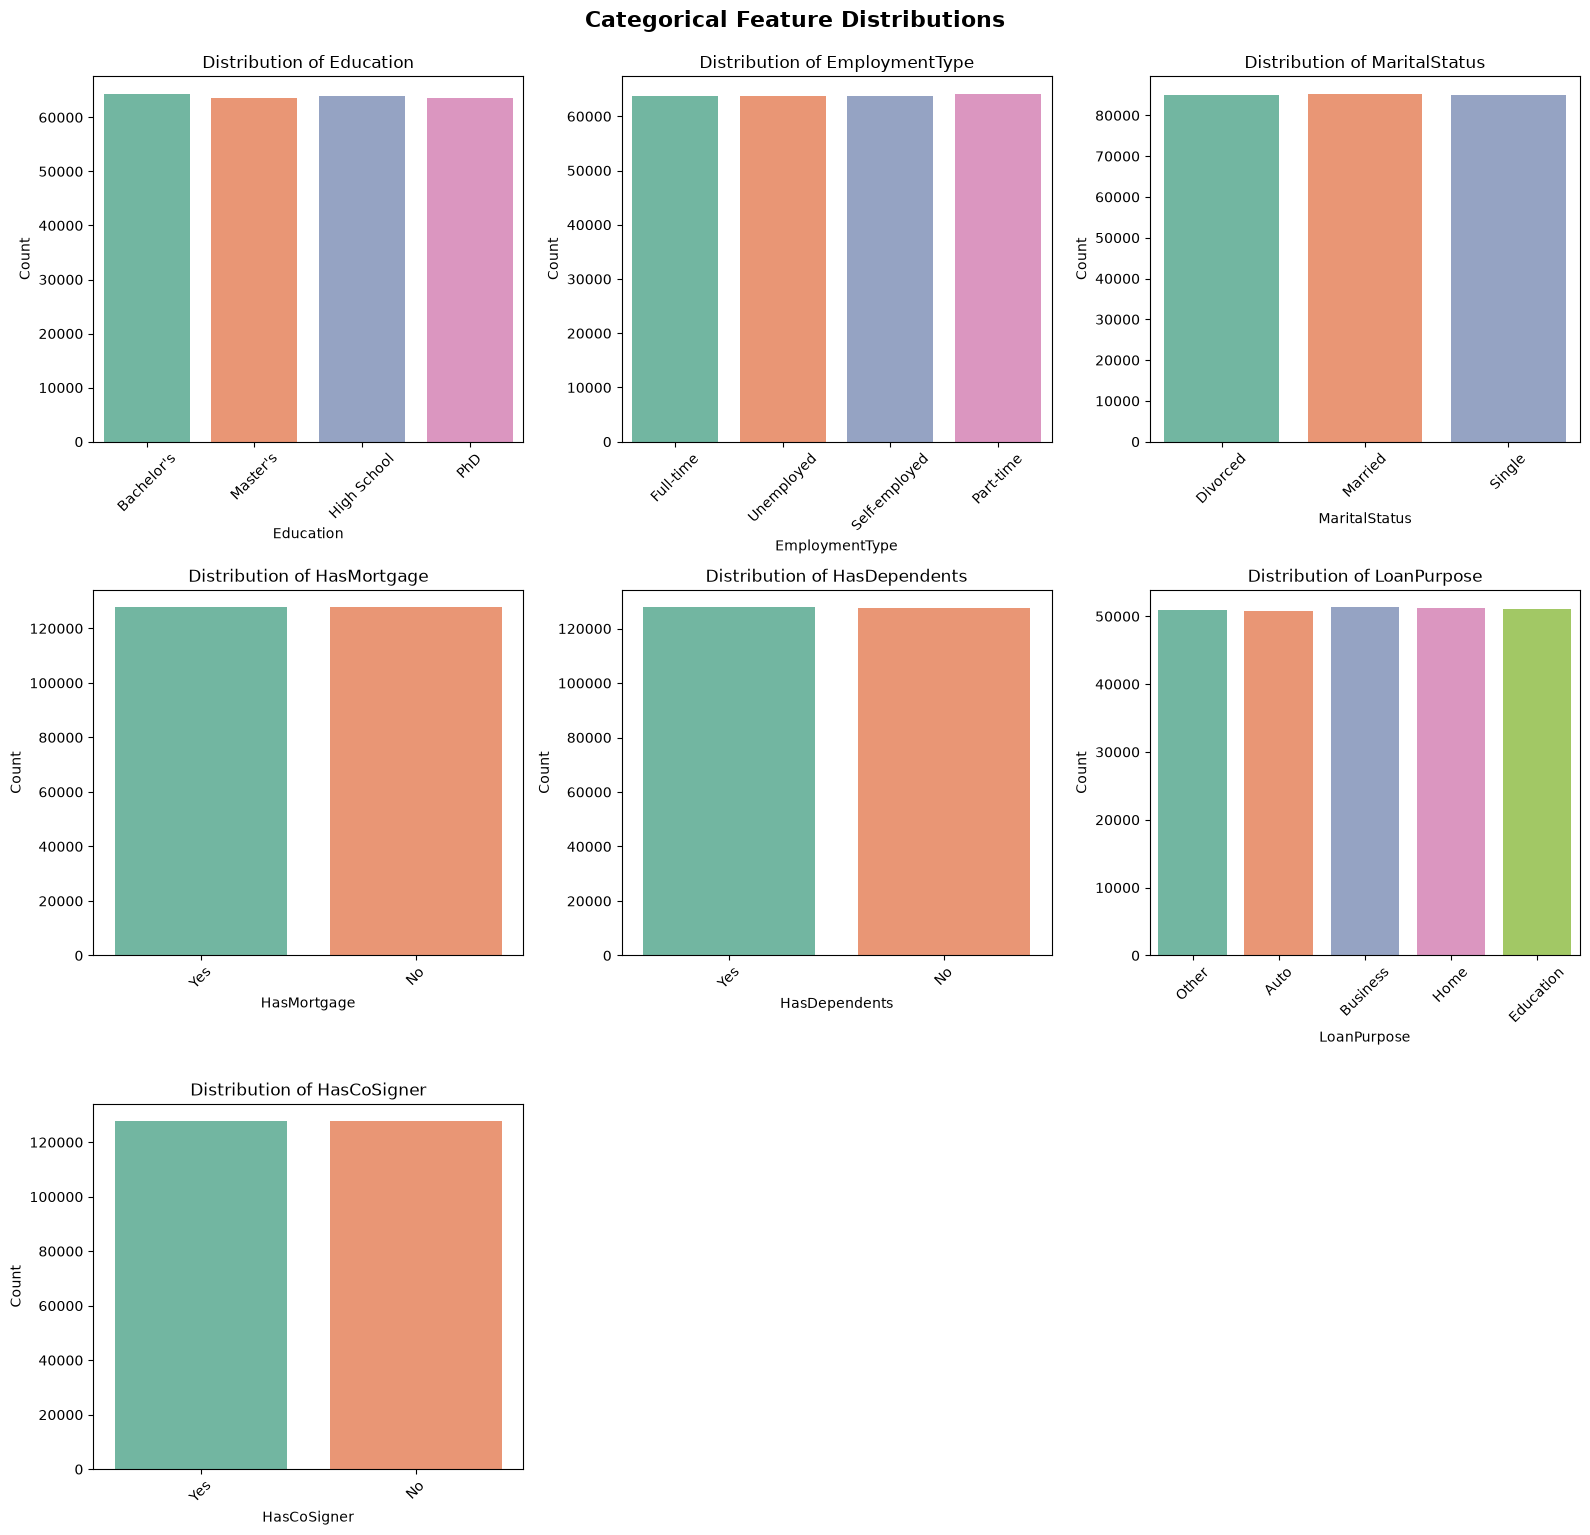

In [12]:
# Visualizing Categorical Feature Distributions
plt.figure(figsize=(16, 15))
for i, feature in enumerate(categorical_columns, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=feature, palette='Set2')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle("Categorical Feature Distributions", fontsize=16, y=1.02, fontweight='bold')
plt.savefig('../images/categorical_feature_univariate_distributions.png', bbox_inches='tight')
plt.show()

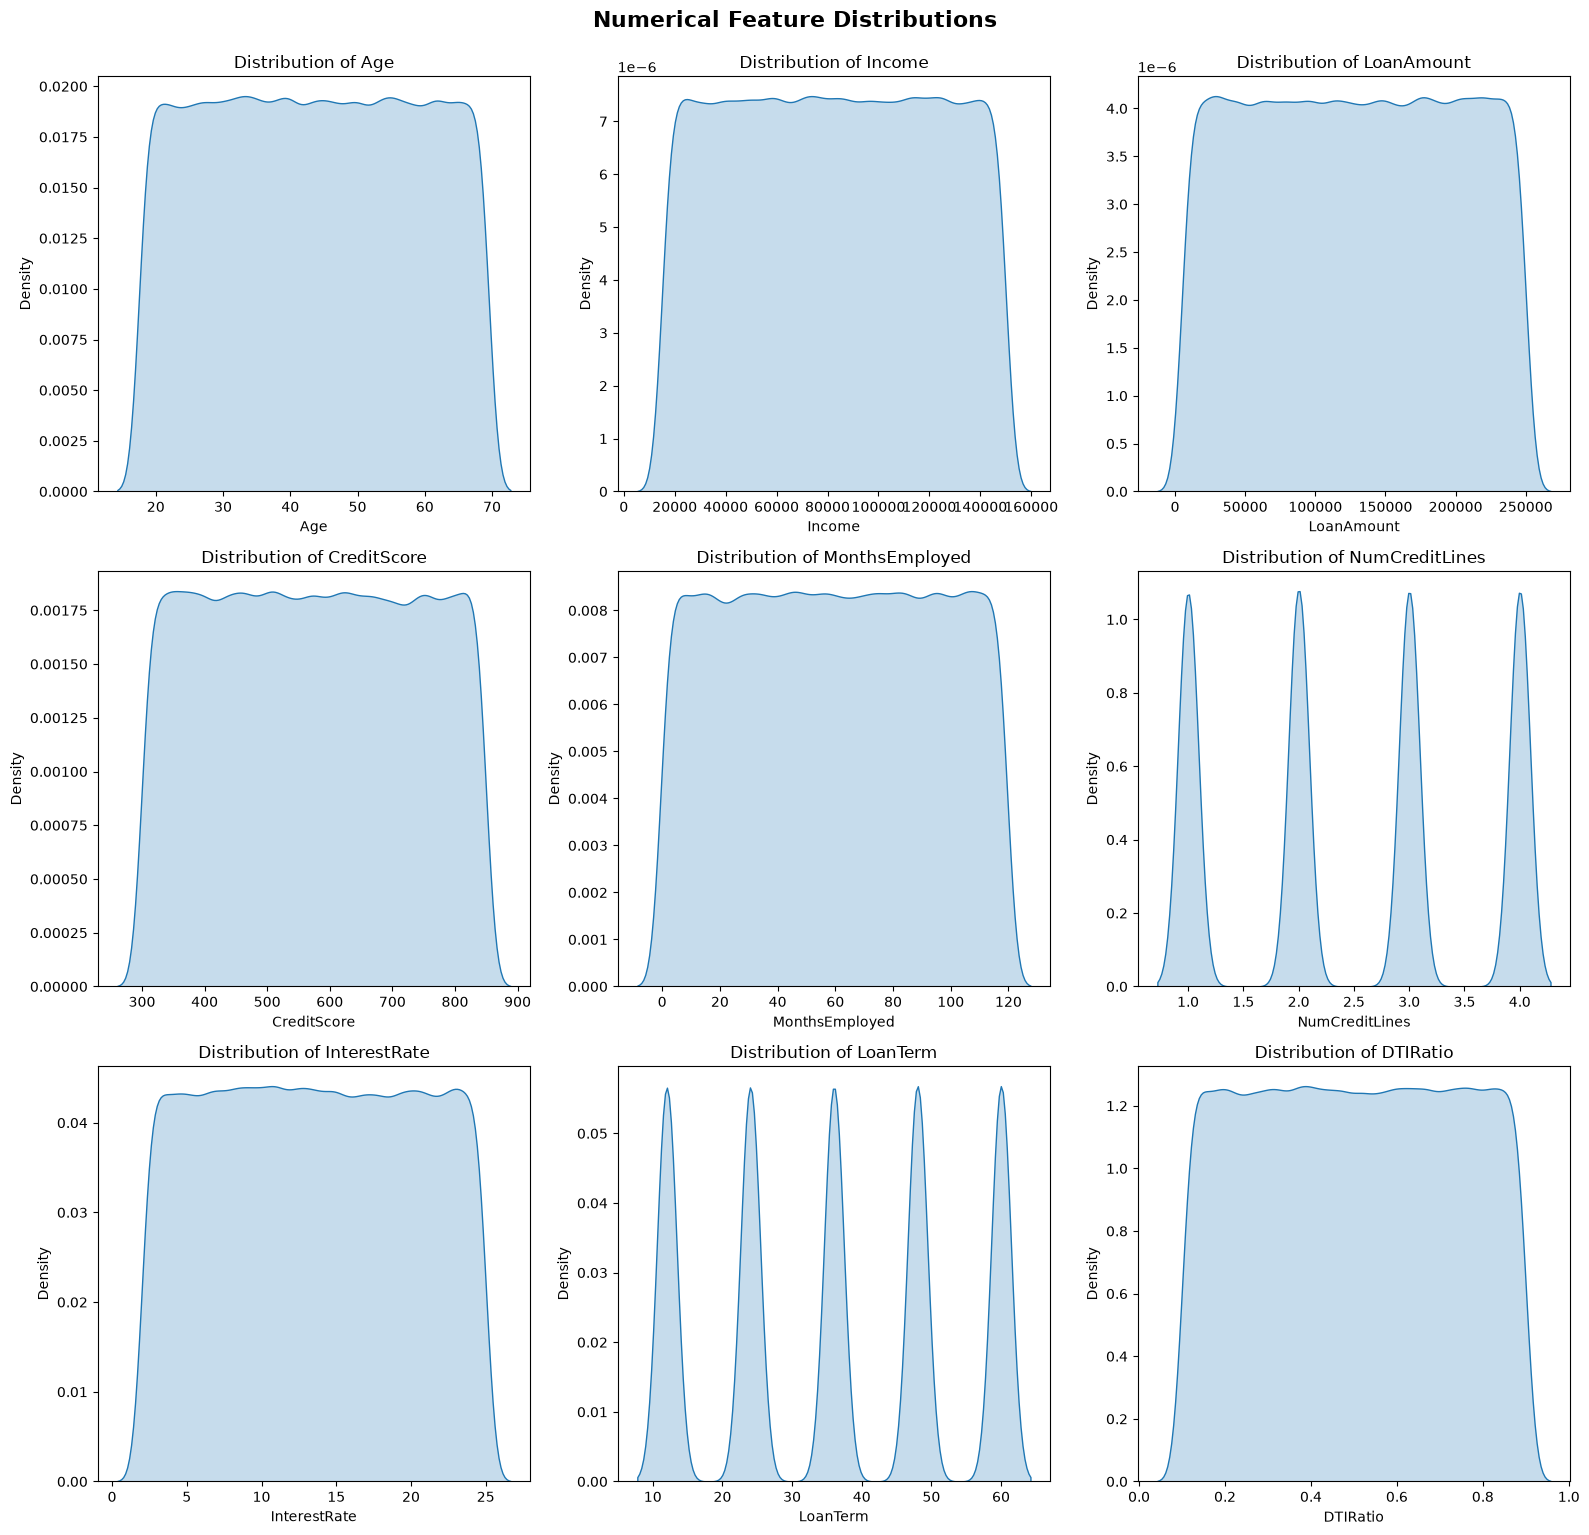

In [13]:
# Visualizing Numerical Feature Distributions
numerical_features = [column for column in numerical_columns if column != "Default"]

plt.figure(figsize=(16, 15))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data=df, x=feature, fill=True, common_norm=False, palette='Set2')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')

plt.tight_layout()
plt.suptitle("Numerical Feature Distributions", fontsize=16, y=1.02, fontweight='bold')
plt.savefig('../images/numerical_feature_univariate_distributions.png', bbox_inches='tight')
plt.show()

**Bivariate Analysis**

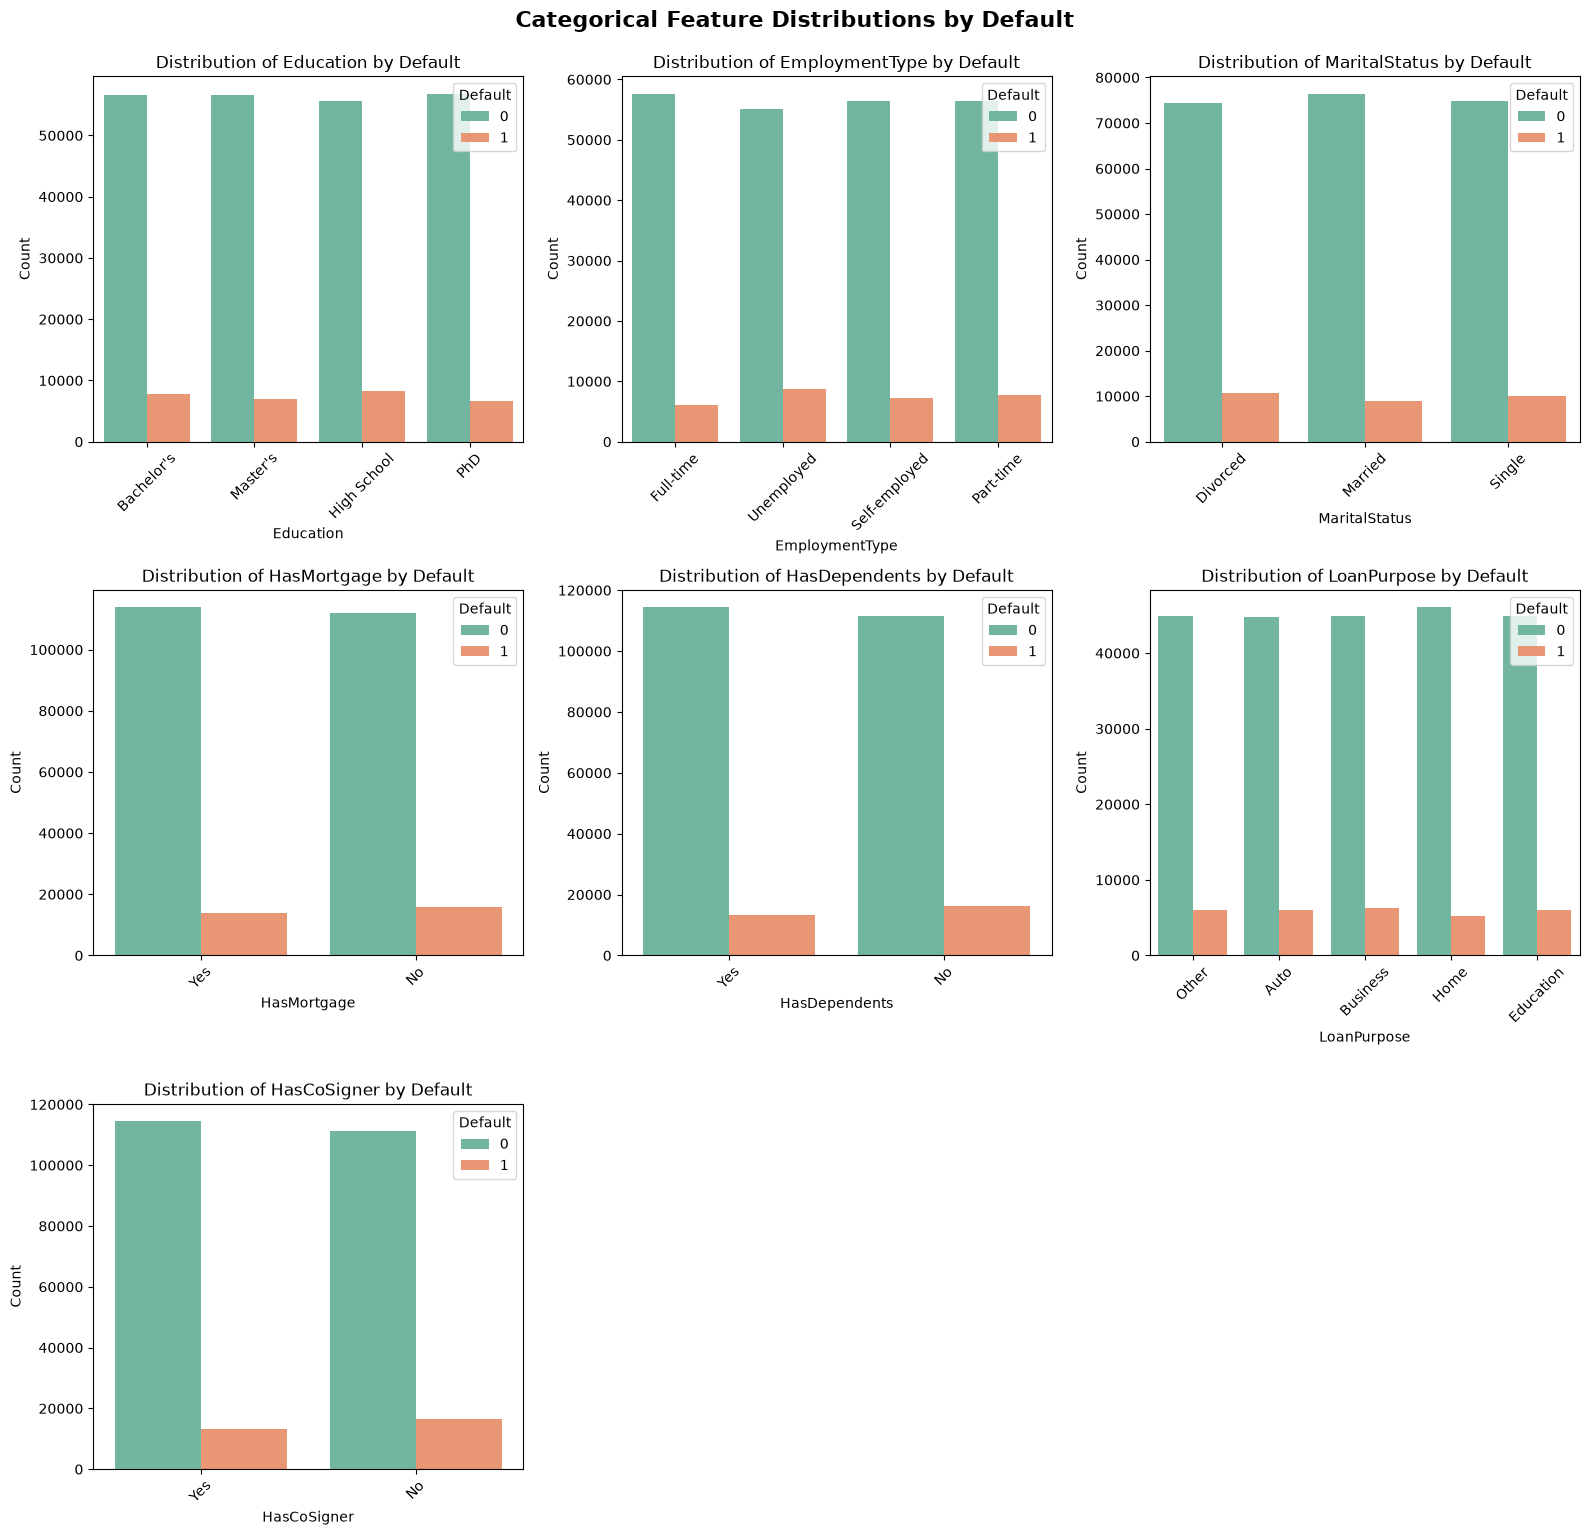

In [14]:
# Visualizing Categorical Feature Distributions by Default
plt.figure(figsize=(16, 15))
for i, feature in enumerate(categorical_columns, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=feature, hue='Default', palette='Set2')
    plt.title(f'Distribution of {feature} by Default')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle("Categorical Feature Distributions by Default", fontsize=16, y=1.02, fontweight='bold')
plt.savefig('../images/categorical_feature_distributions_by_default.png', bbox_inches='tight')
plt.show()

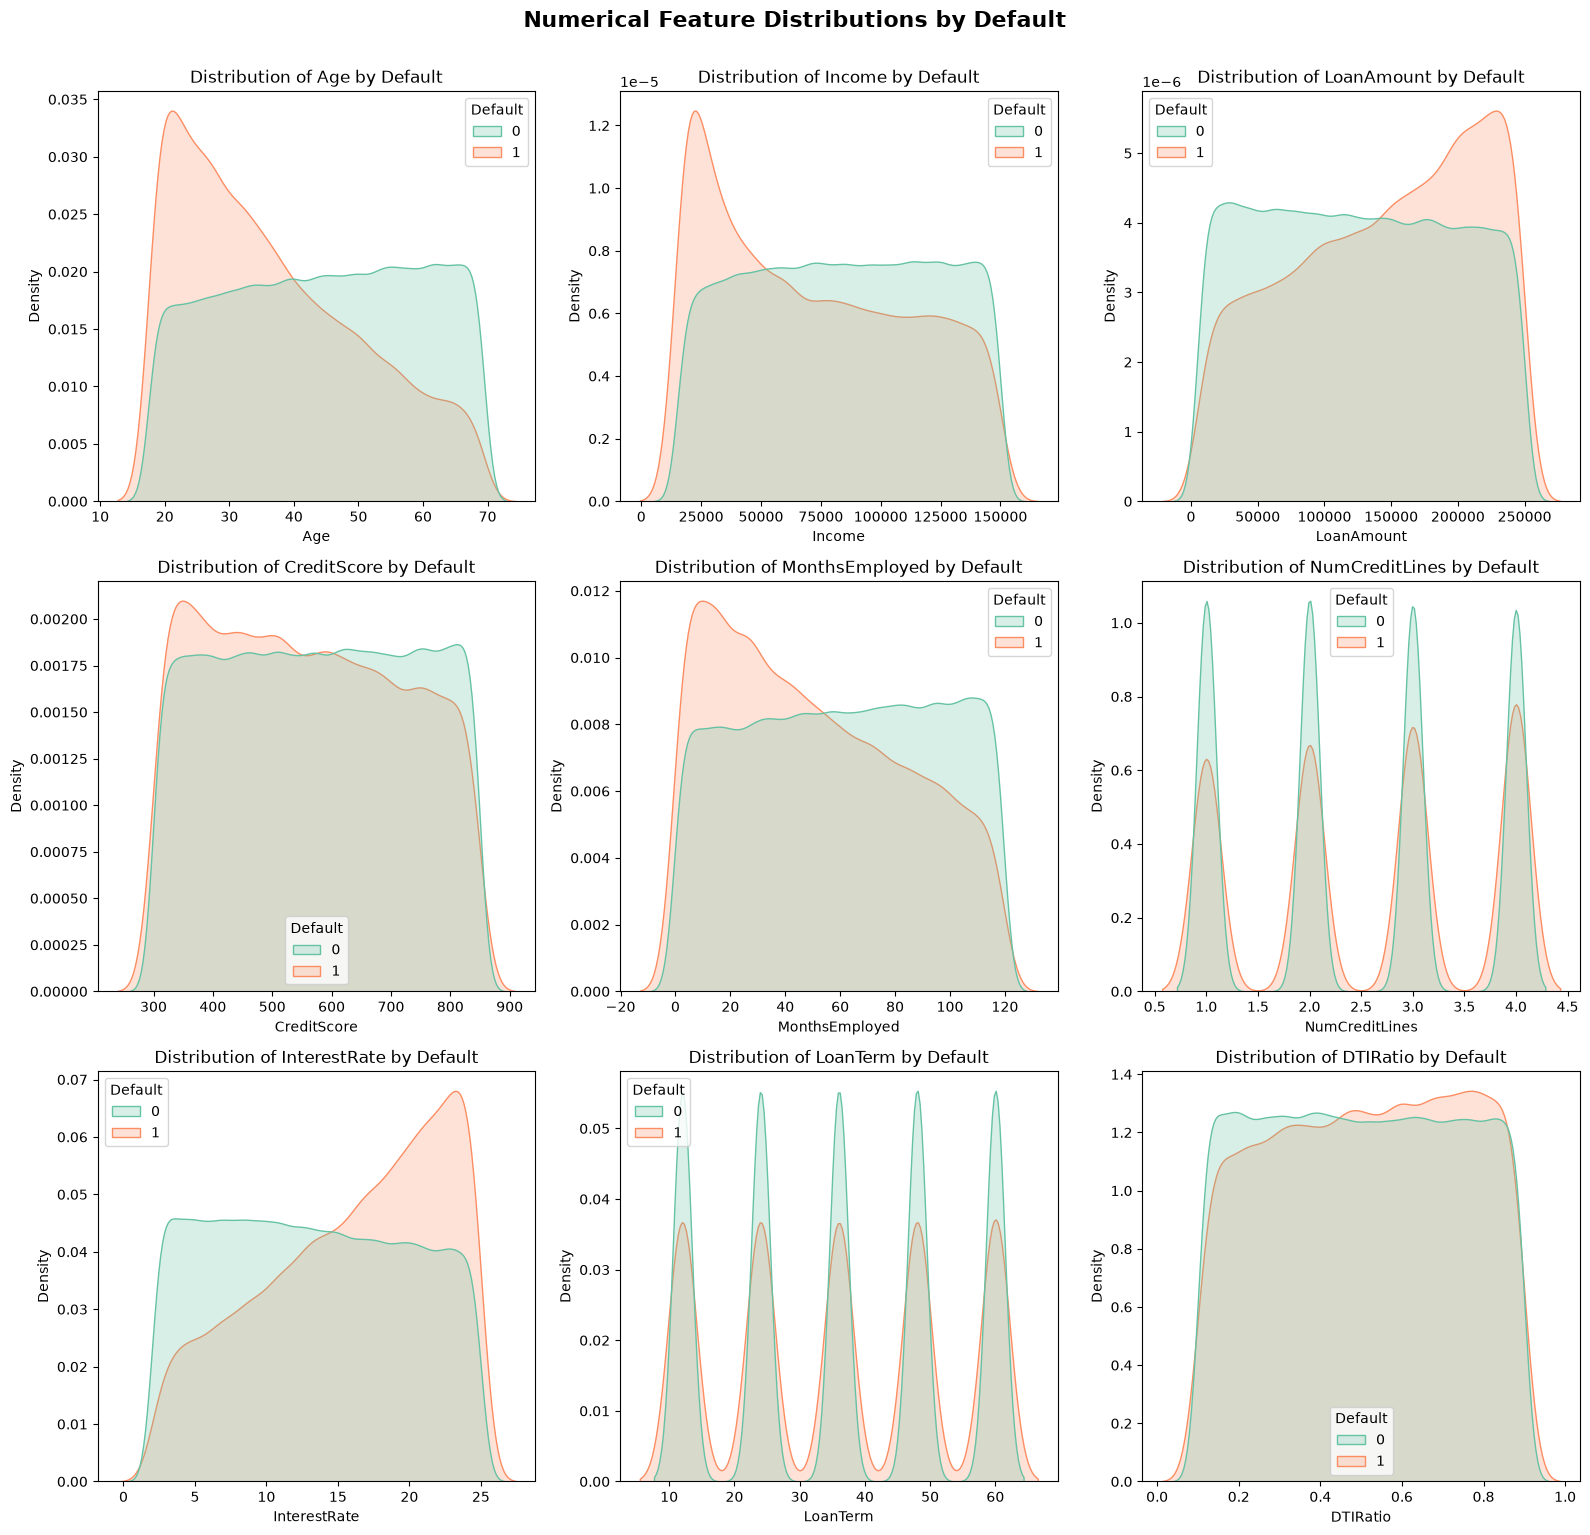

In [15]:
# Visualizing Numerical Feature Distributions by Default
plt.figure(figsize=(16, 15))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data=df, x=feature, hue='Default', fill=True, common_norm=False, palette='Set2')
    plt.title(f'Distribution of {feature} by Default')
    plt.xlabel(feature)
    plt.ylabel('Density')

plt.tight_layout()
plt.suptitle("Numerical Feature Distributions by Default", fontsize=16, y=1.02, fontweight='bold')
plt.savefig('../images/numerical_feature_distributions_by_default.png', bbox_inches='tight')
plt.show()

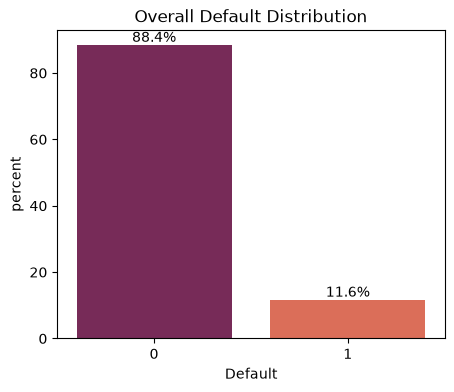

In [16]:
# What is the overall default rate?
plt.figure(figsize=(5, 4))

ax = sns.countplot(x='Default', data=df, stat='percent', hue='Default', palette='rocket', legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Overall Default Distribution')
plt.savefig('../images/default_distribution.png', bbox_inches='tight')
plt.show()

**Insight**
* About 88.4% of customers have fully paid the loan while 11.6% customers have defaulted the loan.

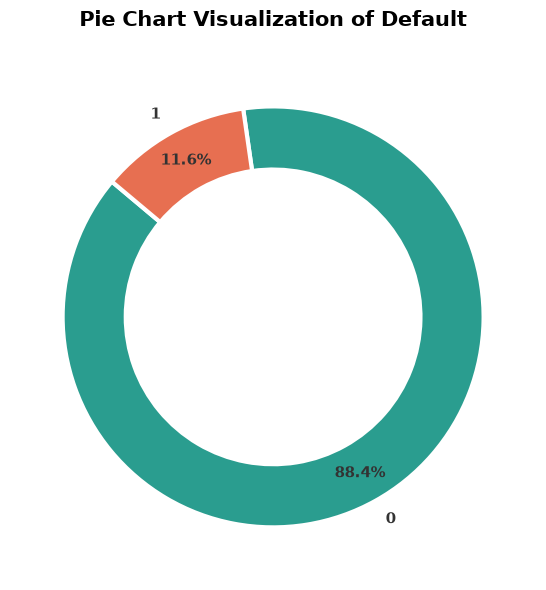

In [17]:
# Pie chart for default distribution
counts = df["Default"].value_counts()
plt.figure(figsize=(6, 6))
colors = ["#2A9D8F", "#E76F51"]
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=140, colors=colors, pctdistance=0.85, textprops={"fontsize": 11, "weight": "bold", "color": "#333333"}, wedgeprops={"width": 0.3, "edgecolor": "white", "linewidth": 3},)
plt.title("Pie Chart Visualization of Default", fontsize=15, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig('../images/default_pie_visualization.png', bbox_inches='tight')
plt.show()

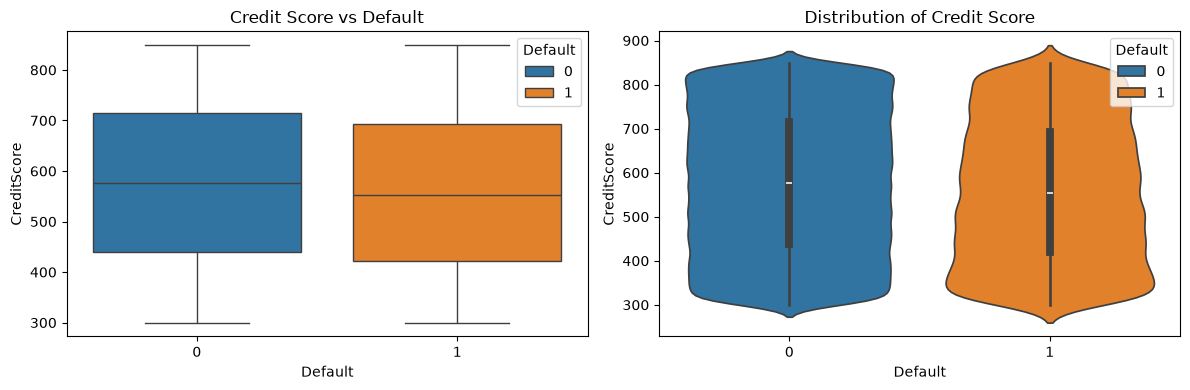

In [18]:
# Do borrowers with lower credit scores default more?
fig, axes = plt.subplots(1,2, figsize=(12,4)) 
sns.boxplot(x='Default', y='CreditScore', hue='Default', data=df, ax=axes[0]) 
axes[0].set_title('Credit Score vs Default') 

sns.violinplot(x='Default', y='CreditScore', hue='Default', data=df, ax=axes[1]) 
axes[1].set_title('Distribution of Credit Score') 

plt.tight_layout() 
plt.savefig('../images/credit_score_distribution.png', bbox_inches='tight')
plt.show()

**Insight**
* Credit scores look nearly identical for both successful payers and those who default on their loans.

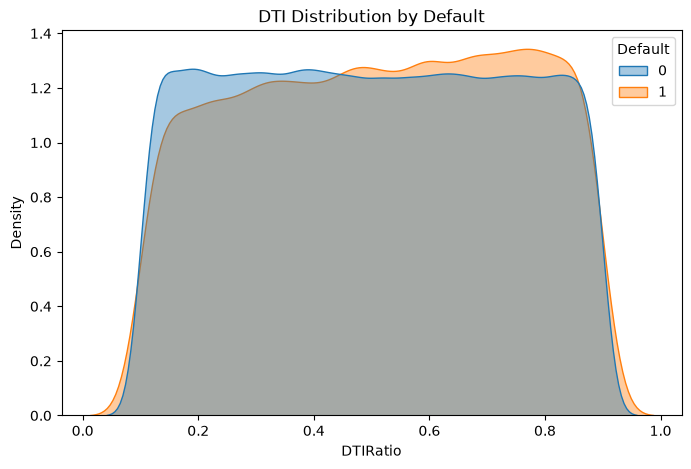

In [19]:
# Does debt-to-income ratio (DTI) increase default risk?
plt.figure(figsize=(8,5)) 
sns.kdeplot(data=df, x='DTIRatio', hue='Default', fill=True, common_norm=False, alpha=0.4) 
plt.title('DTI Distribution by Default') 
plt.savefig('../images/dti_distribution.png', bbox_inches='tight')
plt.show()

**Insight**
* A borrower's debt to income ratio shows almost no meaningful relationship between those who pay and those who default.

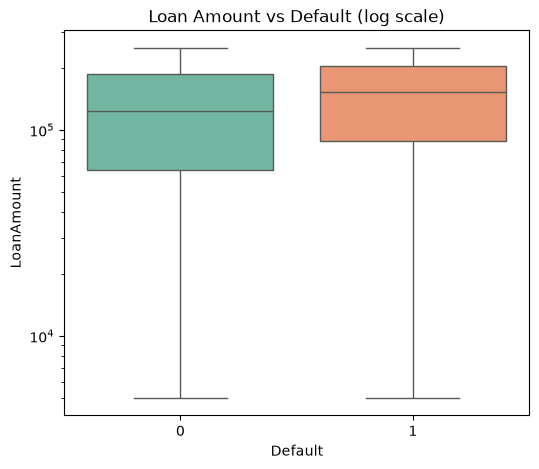

In [20]:
# Are larger loans more likely to default?
plt.figure(figsize=(6,5)) 
sns.boxplot(x='Default', y='LoanAmount', data=df, palette='Set2') 
plt.yscale('log')
plt.title('Loan Amount vs Default (log scale)') 
plt.savefig('../images/loan_amount_distribution.png', bbox_inches='tight')
plt.show()

**Insight**
* Borrowers who are failing to repay their loans tend to request slightly larger loan amounts on average overall.

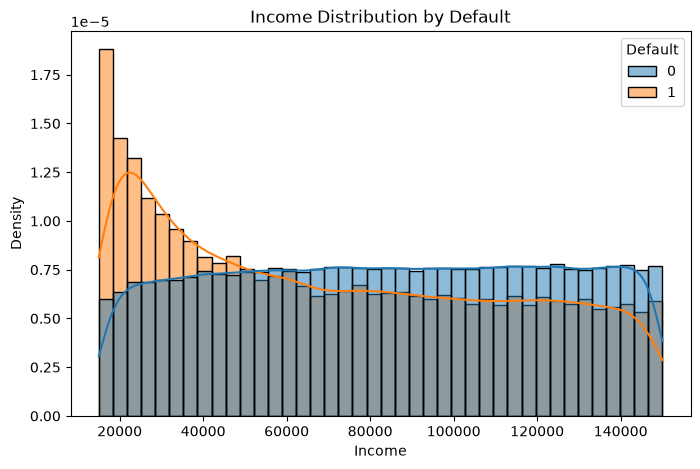

In [21]:
# How does income relate to default?
plt.figure(figsize=(8,5)) 
sns.histplot(data=df, x='Income', hue='Default', bins=40, kde=True, stat='density', common_norm=False) 
plt.title('Income Distribution by Default') 
plt.savefig('../images/income_distribution.png', bbox_inches='tight')
plt.show()

**Insight**
* People who default on their loans generally earn noticeably lower annual incomes compared to successful, reliable loan payers.

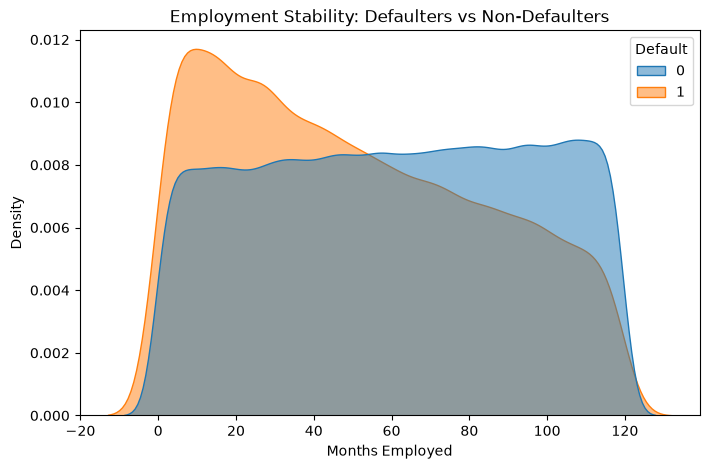

In [22]:
# Does employment stability matter?
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='MonthsEmployed', hue='Default', fill=True, common_norm=False, alpha=0.5)
plt.title('Employment Stability: Defaulters vs Non-Defaulters')
plt.xlabel('Months Employed')
plt.savefig('../images/employment_stability.png', bbox_inches='tight')
plt.show()

**Insight**
* Borrower with less employment month are tends to default more than borrower with stable employment.

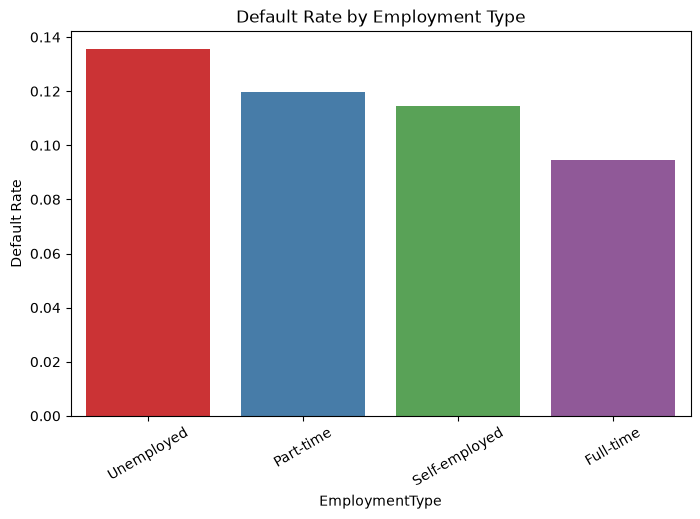

In [23]:
# Which employment types are riskiest?
employment_types = (df.groupby('EmploymentType')['Default'].mean().sort_values(ascending=False)) 
plt.figure(figsize=(8,5)) 
sns.barplot(x=employment_types.index, y=employment_types.values, palette='Set1') 
plt.xticks(rotation=30) 
plt.ylabel('Default Rate') 
plt.title('Default Rate by Employment Type') 
plt.savefig('../images/employment_types.png', bbox_inches='tight')
plt.show()

**Insight**
* Unemployed individuals show the highest risk of defaulting, while full-time workers consistently show the lowest overall risk.

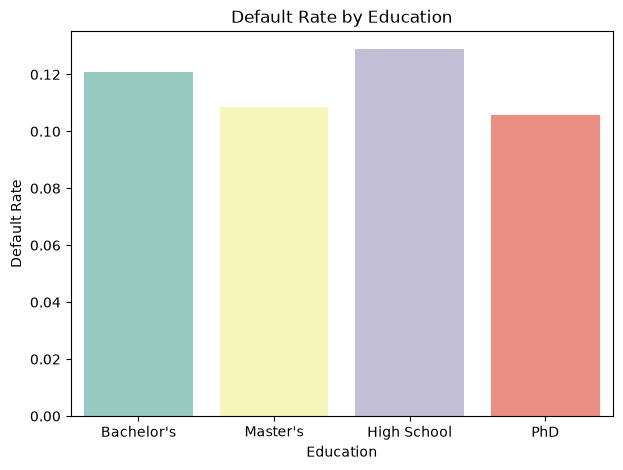

In [24]:
# Does education level affect default?
plt.figure(figsize=(7,5)) 
sns.barplot(data=df, x='Education', y='Default', errorbar=None, palette='Set3') 
plt.ylabel('Default Rate') 
plt.title('Default Rate by Education') 
plt.savefig('../images/education_default.png', bbox_inches='tight')
plt.show()

**Insight**
* Borrowers holding only a high school diploma represent the highest risk group for failing to repay their loans.

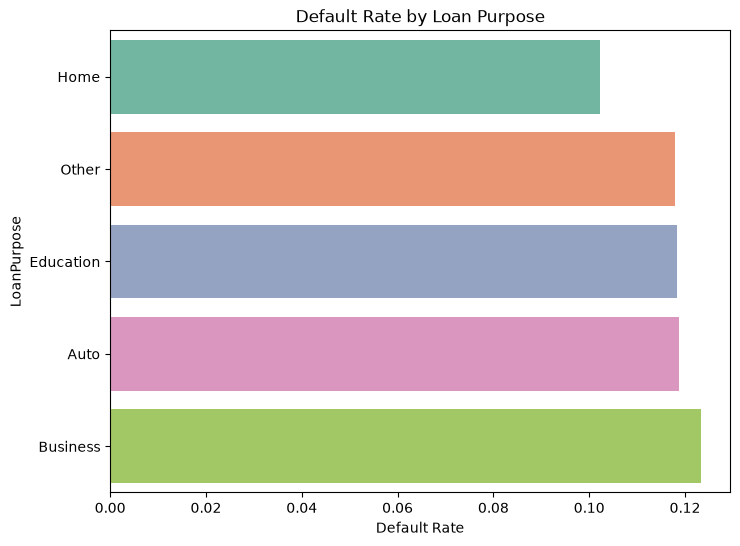

In [25]:
# Which loan purposes have the highest risk?
loan_purposes = (df.groupby('LoanPurpose')['Default'].mean().sort_values())
plt.figure(figsize=(8,6)) 
sns.barplot(x=loan_purposes.values, y=loan_purposes.index, palette='Set2') 
plt.xlabel('Default Rate') 
plt.title('Default Rate by Loan Purpose') 
plt.savefig('../images/default_by_loan_purpose.png', bbox_inches='tight')
plt.show()

**Insight**
* Loans taken out for business purposes carry the highest default risk, while home loans remain the safest.

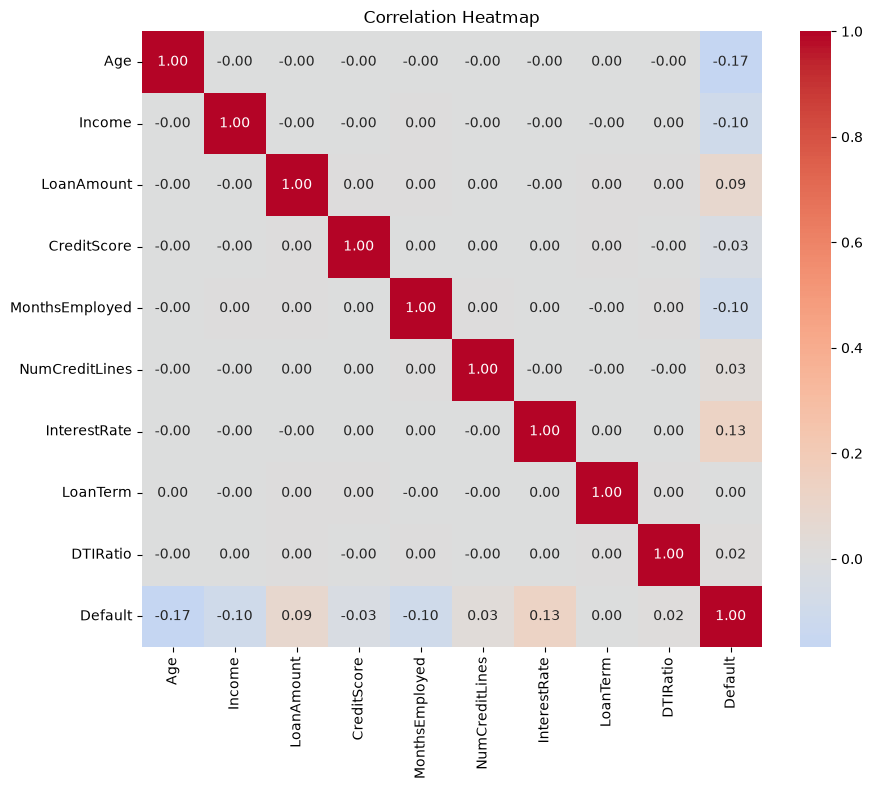

In [26]:
# What variables are most correlated with default?
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('../images/correlation_heatmap.png', bbox_inches='tight')
plt.show()


**Insight**
* Most numerical features show weak relationships, with borrower age and interest rates only slightly affecting loan defaults.

## Feature Engineering

In [27]:
# To check someone earning 5k and asking for 50k loan = risky
df['Loan_to_Income'] = df['LoanAmount'] / df['Income']

In [28]:
# High credit lines + low income = risky
df['Income_per_CreditLine'] = df['Income'] / (df['NumCreditLines'] + 1)

In [29]:
# Stable Employment = Stable Candidate
df['Employment_Stability'] = df['MonthsEmployed'] / (df['Age'] + 1)

In [30]:
# Higher Interest = High Pressure = Risky
df['Interest_Burden'] = df['LoanAmount'] * df['InterestRate']

In [31]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,...,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Loan_to_Income,Income_per_CreditLine,Employment_Stability,Interest_Burden
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,...,Divorced,Yes,Yes,Other,Yes,0,0.588262,17198.80,1.403509,770440.01
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,...,Married,No,No,Other,Yes,0,2.467481,25216.00,0.214286,598556.40
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,...,Divorced,Yes,Yes,Auto,No,1,1.534154,21052.00,0.553191,2734909.96
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,...,Married,No,No,Business,No,0,1.412638,7928.25,0.000000,316728.93
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,...,Divorced,No,Yes,Auto,No,0,0.447179,4087.40,0.131148,59494.89


In [32]:
df.shape

(255347, 21)

In [33]:
df.isnull().sum()

Age                      0
Income                   0
LoanAmount               0
CreditScore              0
MonthsEmployed           0
NumCreditLines           0
InterestRate             0
LoanTerm                 0
DTIRatio                 0
Education                0
EmploymentType           0
MaritalStatus            0
HasMortgage              0
HasDependents            0
LoanPurpose              0
HasCoSigner              0
Default                  0
Loan_to_Income           0
Income_per_CreditLine    0
Employment_Stability     0
Interest_Burden          0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

## Model Training

**Splitting features into X and y**

In [35]:
X = df.drop('Default', axis=1)
y = df['Default']

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [37]:
X_train.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Loan_to_Income,Income_per_CreditLine,Employment_Stability,Interest_Burden
15826,45,37039,247916,624,19,2,4.62,60,0.85,High School,Unemployed,Married,No,Yes,Auto,No,6.693377,12346.333333,0.413043,1145371.92
147371,48,133963,66275,494,119,3,14.72,48,0.49,PhD,Self-employed,Married,Yes,Yes,Other,Yes,0.494726,33490.750000,2.428571,975568.00
178180,47,100204,6967,718,108,3,5.51,24,0.76,High School,Self-employed,Single,Yes,Yes,Business,Yes,0.069528,25051.000000,2.250000,38388.17
126915,42,36078,25966,344,2,3,18.29,36,0.76,Bachelor's,Self-employed,Married,No,Yes,Education,No,0.719718,9019.500000,0.046512,474918.14
163930,20,99464,248557,318,74,3,19.45,60,0.45,Bachelor's,Part-time,Divorced,No,No,Auto,Yes,2.498964,24866.000000,3.523810,4834433.65


In [38]:
len(X_train), len(X_test), len(y_train), len(y_test)

(204277, 51070, 204277, 51070)

**Pipeline**

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [40]:
numerical_cols = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 
    'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 
    'Loan_to_Income', 'Income_per_CreditLine', 'Employment_Stability', 'Interest_Burden'
]

categorical_cols = [
    'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 
    'HasDependents', 'LoanPurpose', 'HasCoSigner'
]

numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="median")),
    ('scale', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", numeric_pipeline, numerical_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

**Baseline Model Training**

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

In [42]:
results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    
    # Creates a full pipeline combining preprocessor and the model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Stores metrics
    results.append([name, accuracy, precision, recall, f1])

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

results_df = results_df.sort_values(by="Recall", ascending=False)
print("\n\n Baseline Model Comparison:")
print(results_df)


Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.69      0.80     45139
           1       0.23      0.70      0.34      5931

    accuracy                           0.69     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.69      0.74     51070


Confusion Matrix:
[[31130 14009]
 [ 1797  4134]]

Model: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     45139
           1       0.19      0.19      0.19      5931

    accuracy                           0.81     51070
   macro avg       0.54      0.54      0.54     51070
weighted avg       0.81      0.81      0.81     51070


Confusion Matrix:
[[40447  4692]
 [ 4825  1106]]

Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93    

**Tuned Logistic Model**

In [43]:
from sklearn.model_selection import GridSearchCV

lr_pipeline = Pipeline(steps=[ 
    ('preprocessor', preprocessor), 
    ('classifier', LogisticRegression(max_iter=1000)) 
])

lr_params = { 
    'classifier__C': [0.01, 0.1, 1, 10], 
    'classifier__penalty': ['l2'], 
    'classifier__class_weight': [None, 'balanced'] 
    }

lr_model = GridSearchCV( 
    lr_pipeline,
    lr_params, 
    cv=5, 
    scoring='recall', 
    n_jobs=-1 
)

lr_model.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ver

In [44]:
print(lr_model.best_params_) 
print(lr_model.best_score_)

{'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}
0.6859452303569746


**Tuned Decision Tree**

In [45]:
dt_pipeline = Pipeline(steps=[ 
    ('preprocessor', preprocessor), 
    ('classifier', DecisionTreeClassifier(random_state=42)) 
])

dt_params = { 
    'classifier__max_depth': [3, 5, 10, 20], 
    'classifier__min_samples_split': [2, 5, 10], 
    'classifier__min_samples_leaf': [1, 2, 5], 
    'classifier__class_weight': [None, 'balanced'] 
}

dt_model = GridSearchCV( 
    dt_pipeline, dt_params, 
    cv=5, 
    scoring='recall', 
    n_jobs=-1 ) 

dt_model.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': [None, 'balanced'], 'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versio

In [46]:
print(dt_model.best_params_) 
print(dt_model.best_score_)

{'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10}
0.6271384896145228


**Tuned Random Forest**

In [48]:
rf_pipeline = Pipeline(steps=[ 
    ('preprocessor', preprocessor), 
    ('classifier', RandomForestClassifier(random_state=42)) 
])

rf_params = {
    'classifier__n_estimators': [300, 500],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__class_weight': ['balanced']
}

rf_model = GridSearchCV( 
    rf_pipeline, 
    rf_params, 
    cv=5, 
    scoring='recall', 
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': ['balanced'], 'classifier__max_depth': [10, 20, ...], 'classifier__min_samples_leaf': [1, 2], 'classifier__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:

In [49]:
print(rf_model.best_params_) 
print(rf_model.best_score_)

{'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}
0.6316497529128913


**Tuned Gradient Booster**

In [50]:
gb_pipeline = Pipeline(steps=[ 
    ('preprocessor', preprocessor), 
    ('classifier', GradientBoostingClassifier(random_state=42)) 
])

gb_params = { 
    'classifier__n_estimators': [100], 
    'classifier__learning_rate': [0.05, 0.1], 
    'classifier__max_depth': [3, 5], 
    'classifier__subsample': [0.8] 
}

gb_model = GridSearchCV( 
    gb_pipeline, 
    gb_params, 
    cv=5, 
    scoring='recall', 
    n_jobs=-1 
)

gb_model.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [3, 5], 'classifier__n_estimators': [100], 'classifier__subsample': [0.8]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callabl

In [51]:
print(gb_model.best_params_) 
print(gb_model.best_score_)

{'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
0.07592129462627742


**Evaluation Table after hyperparameter optimization**

In [52]:
table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
    ],
    "Recall": [
        lr_model.best_score_,
        dt_model.best_score_,
        rf_model.best_score_,
        gb_model.best_score_,
    ]
})

table.sort_values(by="Recall", ascending=False)

,Model,Recall
0,Logistic Regression,0.685945
2,Random Forest,0.631650
1,Decision Tree,0.627138
3,Gradient Boosting,0.075921


In [53]:
best_model = lr_model.best_estimator_
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Age','Income','LoanAmount',...,'Income_per_CreditLine', 'Employment_Stability','Interest_Burden']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [54]:
print("Best Model: Logistic Regression")
print("Recall:", lr_model.best_score_)

Best Model: Logistic Regression
Recall: 0.6859452303569746


In [55]:
import joblib
joblib.dump(best_model, "../model/loan_default_risk_model.pkl")

['../model/loan_default_risk_model.pkl']

**Feature Importance**

In [56]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_model.named_steps['classifier'].coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

In [57]:
feature_importance['Importance'] = abs(feature_importance['Coefficient'])

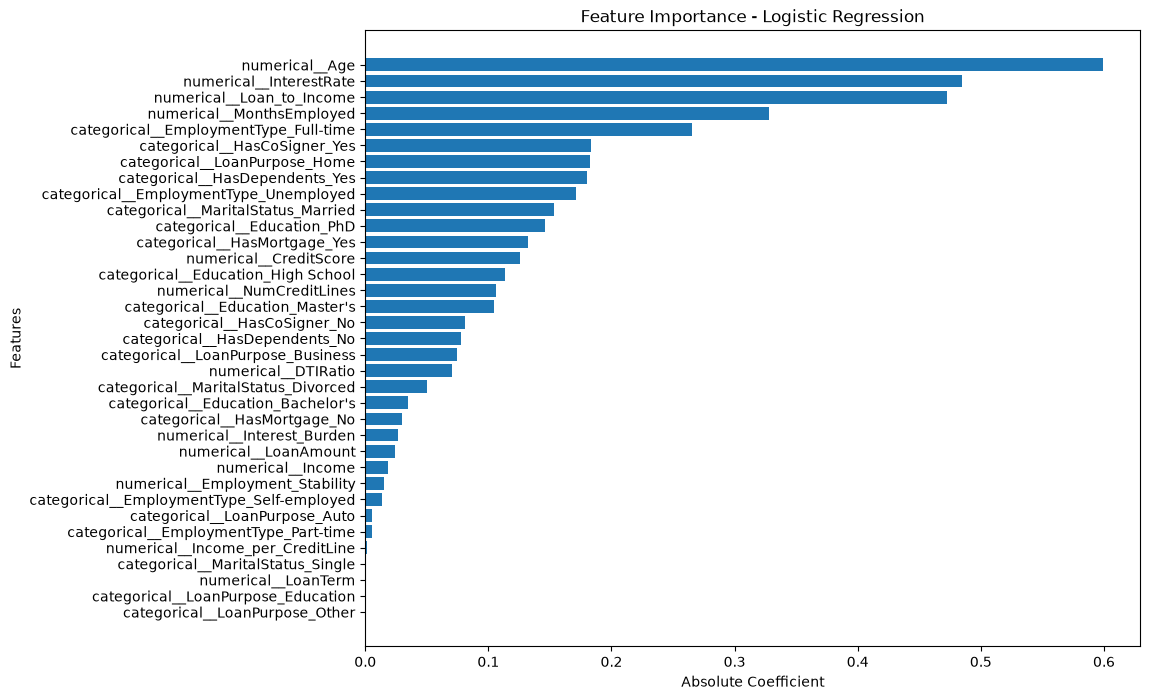

In [58]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel('Absolute Coefficient')
plt.ylabel('Features')
plt.title('Feature Importance - Logistic Regression')
plt.show()